In [1]:
import numpy as np
import pandas as pd
import utils
import pickle

from scipy.stats import loguniform, uniform, randint
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [2]:
with open(f'data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

In [3]:
# Create a tuning subset
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=100000, random_state=42)

# Initialize the base model
gb_base = HistGradientBoostingRegressor(random_state=42)

# Define the hyperparameter search space
gb_param_grid = {
    'learning_rate': [1e-3, 1e-2, 1e-1, 1],
    'max_iter': [50, 100, 200, 250, 300, 500],
    'max_depth': [10, 15, 20, 25, 30]
}

# Run the search using custom function
gb_search, best_params, best_score = utils.optimize_hyper_params(gb_base, X_tune, y_tune, gb_param_grid, 'grid')

# Print the metrics
print("\nBEST PARAMETERS: ", best_params)
print(f"BEST CV RMSE:    {-best_score:.16f}")

----- Running GridSearchCV -----
Fitting 3 folds for each of 120 candidates, totalling 360 fits
Total Runtime: 31.0493 seconds

BEST PARAMETERS:  {'learning_rate': 0.1, 'max_depth': 20, 'max_iter': 200}
BEST CV RMSE:    0.0231858025814328


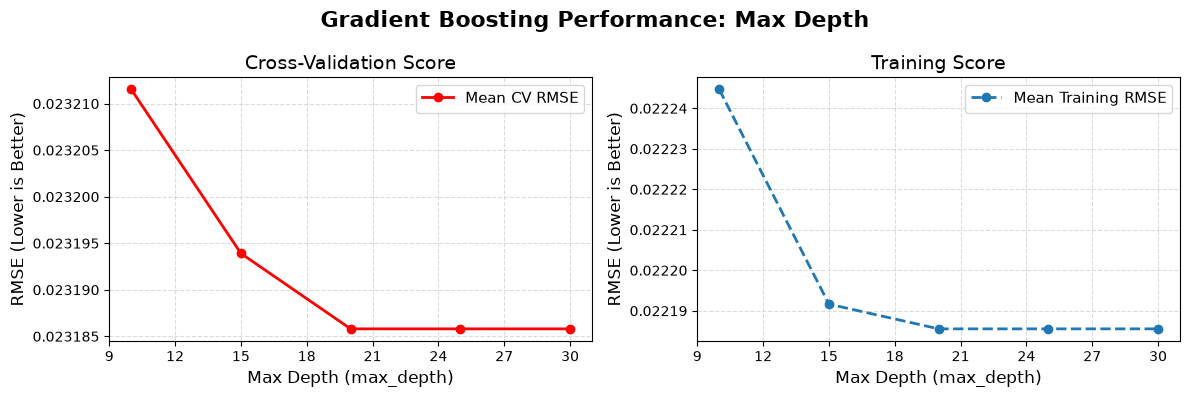

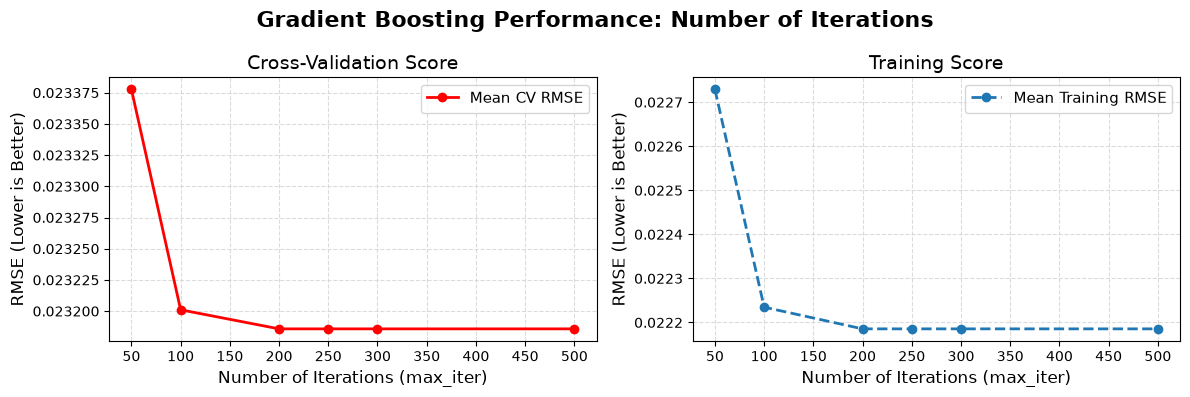

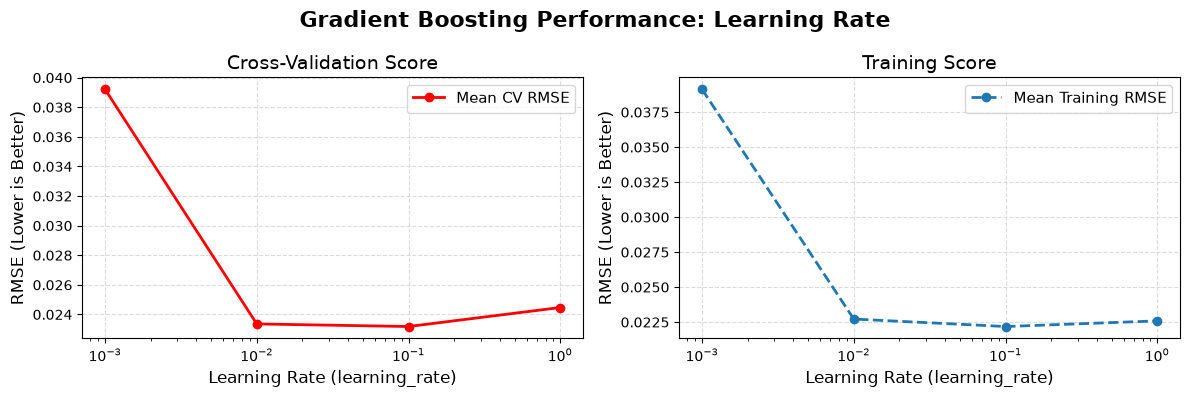

In [4]:
# Plot RMSE vs. Depth
utils.plot_side_by_side_diagnostics(
    search=gb_search, 
    param_name='max_depth', 
    suptitle='Gradient Boosting Performance: Max Depth',
    xlabel_text='Max Depth (max_depth)'
)

# Plot RMSE vs. Number of Iterations
utils.plot_side_by_side_diagnostics(
    search=gb_search, 
    param_name='max_iter', 
    suptitle='Gradient Boosting Performance: Number of Iterations',
    xlabel_text='Number of Iterations (max_iter)'
)

# Plot RMSE vs. Initial Learning Rate
utils.plot_side_by_side_diagnostics(
    search=gb_search, 
    param_name='learning_rate', 
    suptitle='Gradient Boosting Performance: Learning Rate',
    xlabel_text='Learning Rate (learning_rate)',
    log=True
)

In [5]:
# Train a new model with the optimial hyperparameters on the full training set
gb_final = HistGradientBoostingRegressor(**best_params, random_state=42)
gb_final.fit(X_train, y_train)

# Make predictions on the validation set
z_pred_val = gb_final.predict(X_val)

# Calculate and print the metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_val, y_val):.16f}")
print(f"Bias:             {utils.bias(z_pred_val, y_val):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_val, y_val):.16f}")
print("-" * 36)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0248730605776122
Bias:             0.0004837855293754
NMAD:             0.0164023106314274
------------------------------------


In [6]:
# TESTING THE FINAL MODEL
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params}")
print("=" * 36 + "\n")

# Combine train and val data since we don't need the val
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

# Train the final model on the now bigger training set
gb_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 

# Make predictions on the test set
z_pred_test = gb_final.predict(np.array(X_test))

# Calculate and print the final metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_test, y_test):.16f}")
print(f"Bias:             {utils.bias(z_pred_test, y_test):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_test, y_test):.16f}")
print("-" * 36)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'learning_rate': 0.1, 'max_depth': 20, 'max_iter': 200}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0238128886376484
Bias:             0.0004433321734412
NMAD:             0.0162589102759891
------------------------------------
